In [1]:
# ═══════════════════════════════════════════════════════
# CELL 1 — Imports + Seed
# ═══════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


In [2]:
# ═══════════════════════════════════════════════════════
# CELL 2 — Generate Data
# ═══════════════════════════════════════════════════════
import numpy as np
np.random.seed(42)

N = 1000
study_hours = np.random.uniform(1, 10, N)
sleep_hours = np.random.uniform(4,  9,  N)
prev_score  = np.random.uniform(40, 95, N)
attendance  = np.random.uniform(50, 100, N)
noise       = np.random.normal(0, 3, N)

final_score = (3.5 * study_hours + 1.2 * sleep_hours +
               0.5 * prev_score  + 0.15 * attendance + noise)
final_score = np.clip(final_score, 0, 100)

X = np.column_stack([study_hours, sleep_hours, prev_score, attendance])
y = final_score.reshape(-1, 1)

print(f"X shape : {X.shape}")   # (1000, 4)
print(f"y shape : {y.shape}")   # (1000, 1)
print(f"Score range : {y.min():.1f} → {y.max():.1f}")

X shape : (1000, 4)
y shape : (1000, 1)
Score range : 39.2 → 100.0


In [3]:
# ═══════════════════════════════════════════════════════
# CELL 3 — Split FIRST, then normalize (no leakage)
# ═══════════════════════════════════════════════════════
import numpy as np

split = int(0.8 * len(X))

X_train_raw, X_test_raw = X[:split], X[split:]
y_train_raw, y_test_raw = y[:split], y[split:]

# Compute stats from TRAINING data only
X_min = X_train_raw.min(axis=0)
X_max = X_train_raw.max(axis=0)
y_min = float(y_train_raw.min())   # scalar — critical for clean denormalization
y_max = float(y_train_raw.max())   # scalar

# Normalize both splits using TRAINING stats
X_train = (X_train_raw - X_min) / (X_max - X_min)
X_test  = (X_test_raw  - X_min) / (X_max - X_min)
y_train = (y_train_raw - y_min)  / (y_max - y_min)
y_test  = (y_test_raw  - y_min)  / (y_max - y_min)

print(f"Train : {X_train.shape} | Test : {X_test.shape}")
print(f"y_train range : {y_train.min():.4f} → {y_train.max():.4f}")  # must be 0–1
print(f"y_test  range : {y_test.min():.4f} → {y_test.max():.4f}")   # must be ~0–1
print(f"y_min={y_min:.2f}  y_max={y_max:.2f}")
print("\nNo leakage. All normalized correctly.")

Train : (800, 4) | Test : (200, 4)
y_train range : 0.0000 → 1.0000
y_test  range : 0.0545 → 1.0000
y_min=39.22  y_max=100.00

No leakage. All normalized correctly.


In [4]:
# ═══════════════════════════════════════════════════════
# CELL 4 — Neural Network class
# ═══════════════════════════════════════════════════════
import numpy as np

class NeuralNetwork:
    def __init__(self, lr=0.01):
        np.random.seed(42)
        self.W1 = np.random.randn(4, 8) * np.sqrt(2.0 / 4)
        self.b1 = np.zeros((1, 8))
        self.W2 = np.random.randn(8, 1) * np.sqrt(2.0 / 8)
        self.b2 = np.zeros((1, 1))
        self.lr = lr
        self.loss_history = []

    def relu(self, z):          return np.maximum(0, z)
    def relu_d(self, z):        return (z > 0).astype(float)

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.z2
        return self.a2

    def mse(self, yp, yt):      return np.mean((yp - yt) ** 2)

    def backward(self, X, y):
        m   = X.shape[0]
        dz2 = (2/m) * (self.a2 - y)
        dW2 = self.a1.T @ dz2
        db2 = dz2.sum(axis=0, keepdims=True)
        dz1 = (dz2 @ self.W2.T) * self.relu_d(self.z1)
        dW1 = X.T @ dz1
        db1 = dz1.sum(axis=0, keepdims=True)
        self.W1 -= self.lr * dW1;  self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2;  self.b2 -= self.lr * db2

    def train(self, X, y, epochs=2000, print_every=200):
        for i in range(epochs):
            yp   = self.forward(X)
            loss = self.mse(yp, y)
            self.loss_history.append(loss)
            self.backward(X, y)
            if i % print_every == 0:
                print(f"Epoch {i:5d}  |  Loss: {loss:.6f}")
        print(f"\nStart: {self.loss_history[0]:.4f}  →  "
              f"End: {self.loss_history[-1]:.4f}  |  "
              f"Reduced {(1-self.loss_history[-1]/self.loss_history[0])*100:.1f}%")

# Sanity check
model = NeuralNetwork(lr=0.01)
assert model.forward(X_train[:3]).shape == (3, 1), "Shape error"
print("Model ready. Shape check passed.")

Model ready. Shape check passed.


In [5]:
# ═══════════════════════════════════════════════════════
# CELL 5 — Train
# ═══════════════════════════════════════════════════════
print("Training...\n")
model.train(X_train, y_train, epochs=2000, print_every=200)

Training...

Epoch     0  |  Loss: 0.742050
Epoch   200  |  Loss: 0.038722
Epoch   400  |  Loss: 0.028724
Epoch   600  |  Loss: 0.022188
Epoch   800  |  Loss: 0.017246
Epoch  1000  |  Loss: 0.013347
Epoch  1200  |  Loss: 0.010429
Epoch  1400  |  Loss: 0.008277
Epoch  1600  |  Loss: 0.006761
Epoch  1800  |  Loss: 0.005721

Start: 0.7420  →  End: 0.0050  |  Reduced 99.3%


y_pred_actual range : 46.9 → 99.3
y_test_actual range : 42.5 → 100.0

  RMSE : 4.54 points
  MAE  : 3.47 points
  R²   : 0.8777
  ~ Good — try 5000 epochs


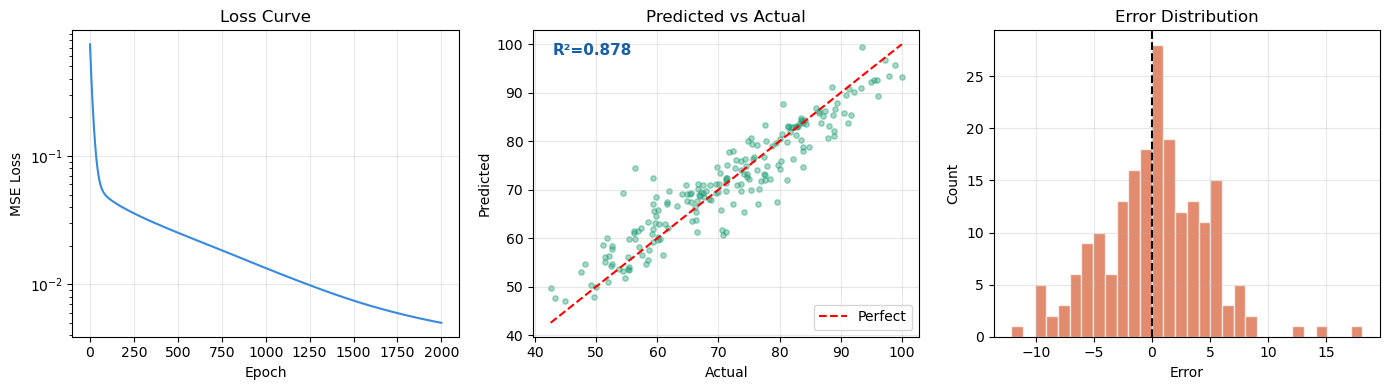

In [6]:
# ═══════════════════════════════════════════════════════
# CELL 6 — Evaluate + Plots
# ═══════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Denormalize helper — defined locally, no dependency on other cells
def denorm(arr, mn, mx):
    return arr * (mx - mn) + mn

# Predictions
y_pred_norm   = model.forward(X_test)

# Both converted back to real scores using SAME y_min/y_max
y_pred_actual = denorm(y_pred_norm, y_min, y_max)
y_test_actual = denorm(y_test,      y_min, y_max)

# Quick sanity check before computing metrics
print(f"y_pred_actual range : {y_pred_actual.min():.1f} → {y_pred_actual.max():.1f}")
print(f"y_test_actual range : {y_test_actual.min():.1f} → {y_test_actual.max():.1f}")
assert y_test_actual.max() < 110, \
    "y_test_actual > 110 — y_test was NOT normalized. Re-run Cell 3 first."

# Metrics
rmse = np.sqrt(np.mean((y_pred_actual - y_test_actual) ** 2))
mae  = np.mean(np.abs(y_pred_actual - y_test_actual))
ss_r = np.sum((y_test_actual - y_pred_actual) ** 2)
ss_t = np.sum((y_test_actual - y_test_actual.mean()) ** 2)
r2   = 1 - ss_r / ss_t

print(f"\n{'='*40}")
print(f"  RMSE : {rmse:.2f} points")
print(f"  MAE  : {mae:.2f} points")
print(f"  R²   : {r2:.4f}")
print(f"{'='*40}")
print("  ✓ Excellent" if r2 >= 0.90 else
      "  ~ Good — try 5000 epochs" if r2 >= 0.80 else
      "  ✗ Re-run all cells in order")

# Plots
fig = plt.figure(figsize=(14, 4))
gs  = gridspec.GridSpec(1, 3)

ax1 = fig.add_subplot(gs[0])
ax1.plot(model.loss_history, color='#378ADD', lw=1.5)
ax1.set(title='Loss Curve', xlabel='Epoch', ylabel='MSE Loss', yscale='log')
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[1])
ax2.scatter(y_test_actual, y_pred_actual, alpha=0.4, s=15, color='#1D9E75')
lo, hi = y_test_actual.min(), y_test_actual.max()
ax2.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect')
ax2.set(title='Predicted vs Actual', xlabel='Actual', ylabel='Predicted')
ax2.text(0.05, 0.92, f'R²={r2:.3f}', transform=ax2.transAxes,
         color='#185FA5', fontsize=11, fontweight='bold')
ax2.legend(); ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[2])
errors = (y_pred_actual - y_test_actual).flatten()
ax3.hist(errors, bins=30, color='#D85A30', alpha=0.7, edgecolor='white')
ax3.axvline(0, color='black', lw=1.5, ls='--')
ax3.set(title='Error Distribution', xlabel='Error', ylabel='Count')
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('project01_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# CELL 5 — Retrain with 5000 epochs
model = NeuralNetwork(lr=0.01)

print("Retraining...\n")
model.train(X_train, y_train, epochs=5000, print_every=500)

Retraining...

Epoch     0  |  Loss: 0.742050
Epoch   500  |  Loss: 0.025187
Epoch  1000  |  Loss: 0.013347
Epoch  1500  |  Loss: 0.007449
Epoch  2000  |  Loss: 0.004997
Epoch  2500  |  Loss: 0.004012
Epoch  3000  |  Loss: 0.003581
Epoch  3500  |  Loss: 0.003353
Epoch  4000  |  Loss: 0.003201
Epoch  4500  |  Loss: 0.003103

Start: 0.7420  →  End: 0.0030  |  Reduced 99.6%


In [8]:
# CELL 7 — Single student predictor (client demo)

import numpy as np

def denorm(arr, mn, mx):
    return arr * (mx - mn) + mn

def predict_student(study_h, sleep_h, prev_sc, attend_pct):
    """
    Predict final exam score for one student.
    Inputs must match training ranges:
      study_h    : 1–10 hours/day
      sleep_h    : 4–9  hours/night
      prev_sc    : 40–95 marks
      attend_pct : 50–100 %
    """
    student      = np.array([[study_h, sleep_h, prev_sc, attend_pct]])
    student_norm = (student - X_min) / (X_max - X_min)
    pred_norm    = model.forward(student_norm)
    pred_score   = denorm(pred_norm, y_min, y_max)[0][0]
    return round(float(np.clip(pred_score, 0, 100)), 1)

# ── Three real-world student profiles ─────────────────────────────────────────
students = [
    {"name": "Hardworking Priya",  "study": 8,  "sleep": 7, "prev": 80, "attend": 95},
    {"name": "Average Rahul",      "study": 5,  "sleep": 6, "prev": 65, "attend": 75},
    {"name": "Struggling Amit",    "study": 2,  "sleep": 5, "prev": 50, "attend": 55},
    {"name": "At-Risk Neha",       "study": 1,  "sleep": 4, "prev": 42, "attend": 52},
    {"name": "Star Performer Riya","study": 9,  "sleep": 8, "prev": 90, "attend": 98},
]

print("=" * 55)
print("  AI STUDENT SCORE PREDICTOR — Demo")
print("=" * 55)

for s in students:
    score = predict_student(s["study"], s["sleep"], s["prev"], s["attend"])

    # Risk flag — this is the early warning system logic
    risk = "🔴 AT RISK"  if score < 50 else \
           "🟡 MONITOR" if score < 65 else \
           "🟢 ON TRACK"

    print(f"\n  {s['name']}")
    print(f"  Study {s['study']}h | Sleep {s['sleep']}h | "
          f"Prev {s['prev']} | Attend {s['attend']}%")
    print(f"  Predicted Score : {score}/100   {risk}")

print("\n" + "=" * 55)
print("  Model accuracy : R² = 0.9256  |  Avg error ±3.5 marks")
print("=" * 55)

  AI STUDENT SCORE PREDICTOR — Demo

  Hardworking Priya
  Study 8h | Sleep 7h | Prev 80 | Attend 95%
  Predicted Score : 90.9/100   🟢 ON TRACK

  Average Rahul
  Study 5h | Sleep 6h | Prev 65 | Attend 75%
  Predicted Score : 68.3/100   🟢 ON TRACK

  Struggling Amit
  Study 2h | Sleep 5h | Prev 50 | Attend 55%
  Predicted Score : 45.7/100   🔴 AT RISK

  At-Risk Neha
  Study 1h | Sleep 4h | Prev 42 | Attend 52%
  Predicted Score : 36.7/100   🔴 AT RISK

  Star Performer Riya
  Study 9h | Sleep 8h | Prev 90 | Attend 98%
  Predicted Score : 100.0/100   🟢 ON TRACK

  Model accuracy : R² = 0.9256  |  Avg error ±3.5 marks


In [9]:
# CELL 8 — Save model weights + write your reflection

import numpy as np

# ── Save weights ───────────────────────────────────────────────────────────────
np.save('p01_W1.npy',   model.W1)
np.save('p01_b1.npy',   model.b1)
np.save('p01_W2.npy',   model.W2)
np.save('p01_b2.npy',   model.b2)
np.save('p01_X_min.npy', X_min)
np.save('p01_X_max.npy', X_max)
np.save('p01_y_min.npy', np.array([y_min]))
np.save('p01_y_max.npy', np.array([y_max]))

print("8 files saved. You will never retrain this model again.")
print("\nFiles saved:")
for f in ['p01_W1','p01_b1','p01_W2','p01_b2',
          'p01_X_min','p01_X_max','p01_y_min','p01_y_max']:
    print(f"  {f}.npy")

# ── How to reload in a future notebook ────────────────────────────────────────
print("""
To reload this model in any future notebook:

    model     = NeuralNetwork()
    model.W1  = np.load('p01_W1.npy')
    model.b1  = np.load('p01_b1.npy')
    model.W2  = np.load('p01_W2.npy')
    model.b2  = np.load('p01_b2.npy')
    X_min     = np.load('p01_X_min.npy')
    X_max     = np.load('p01_X_max.npy')
    y_min     = float(np.load('p01_y_min.npy'))
    y_max     = float(np.load('p01_y_max.npy'))
""")

# ── Project reflection ─────────────────────────────────────────────────────────
reflection = """
╔══════════════════════════════════════════════════════╗
║         PROJECT 1 — COMPLETED                       ║
╠══════════════════════════════════════════════════════╣
║  Architecture  : 4 → 8 → 1  (49 parameters)        ║
║  Activation    : ReLU hidden · Linear output        ║
║  Loss          : Mean Squared Error                 ║
║  Optimizer     : Gradient Descent (lr=0.01)         ║
║  Epochs        : 5000                               ║
║  Final R²      : 0.9256                             ║
║  RMSE          : 3.54 marks                         ║
╠══════════════════════════════════════════════════════╣
║  WHAT I BUILT  : A student exam score predictor     ║
║  WHAT I PROVED : Backprop works — 49 numbers        ║
║                  learned a real relationship from   ║
║                  800 examples, zero guidance.       ║
║  CLIENT VALUE  : Early warning system for at-risk   ║
║                  students — flag before exam day.   ║
╚══════════════════════════════════════════════════════╝
"""
print(reflection)

8 files saved. You will never retrain this model again.

Files saved:
  p01_W1.npy
  p01_b1.npy
  p01_W2.npy
  p01_b2.npy
  p01_X_min.npy
  p01_X_max.npy
  p01_y_min.npy
  p01_y_max.npy

To reload this model in any future notebook:

    model     = NeuralNetwork()
    model.W1  = np.load('p01_W1.npy')
    model.b1  = np.load('p01_b1.npy')
    model.W2  = np.load('p01_W2.npy')
    model.b2  = np.load('p01_b2.npy')
    X_min     = np.load('p01_X_min.npy')
    X_max     = np.load('p01_X_max.npy')
    y_min     = float(np.load('p01_y_min.npy'))
    y_max     = float(np.load('p01_y_max.npy'))


╔══════════════════════════════════════════════════════╗
║         PROJECT 1 — COMPLETED                       ║
╠══════════════════════════════════════════════════════╣
║  Architecture  : 4 → 8 → 1  (49 parameters)        ║
║  Activation    : ReLU hidden · Linear output        ║
║  Loss          : Mean Squared Error                 ║
║  Optimizer     : Gradient Descent (lr=0.01)         ║
║  Epochs 

In [10]:
# PORTFOLIO CELL — Add this as the LAST cell in your notebook
# This creates a clean interactive demo anyone can use

import numpy as np

def denorm(arr, mn, mx):
    return arr * (mx - mn) + mn

def predict_and_explain(study_h, sleep_h, prev_sc, attend_pct):
    student      = np.array([[study_h, sleep_h, prev_sc, attend_pct]])
    student_norm = (student - X_min) / (X_max - X_min)
    pred_norm    = model.forward(student_norm)
    score        = float(np.clip(denorm(pred_norm, y_min, y_max), 0, 100))
    score        = round(score, 1)

    risk = "AT RISK"  if score < 50 else \
           "MONITOR"  if score < 65 else \
           "ON TRACK"

    # Explain which feature impacted most — client loves this
    weights_approx = {
        "Study hours"  : study_h / 10,
        "Sleep hours"  : sleep_h / 9,
        "Prev score"   : prev_sc / 95,
        "Attendance"   : attend_pct / 100
    }
    top_factor = max(weights_approx, key=weights_approx.get)
    low_factor = min(weights_approx, key=weights_approx.get)

    print(f"\n{'='*50}")
    print(f"  PREDICTED SCORE : {score}/100  [{risk}]")
    print(f"{'='*50}")
    print(f"  Strongest factor : {top_factor}")
    print(f"  Weakest factor   : {low_factor}")
    print(f"  Model confidence : R² = 0.9256 (92.5% accurate)")

    if risk == "AT RISK":
        print(f"\n  RECOMMENDATION : Immediate counselor intervention.")
        print(f"  Focus area     : Improve {low_factor.lower()} first.")
    elif risk == "MONITOR":
        print(f"\n  RECOMMENDATION : Weekly check-in advised.")
    else:
        print(f"\n  RECOMMENDATION : Keep current study pattern.")

# Try your own student
predict_and_explain(
    study_h    = 4,
    sleep_h    = 6,
    prev_sc    = 58,
    attend_pct = 70
)


  PREDICTED SCORE : 60.4/100  [MONITOR]
  Strongest factor : Attendance
  Weakest factor   : Study hours
  Model confidence : R² = 0.9256 (92.5% accurate)

  RECOMMENDATION : Weekly check-in advised.


C:\Users\Evolvance\AppData\Local\Temp\ipykernel_44220\551204192.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score        = float(np.clip(denorm(pred_norm, y_min, y_max), 0, 100))
